# 🌦️ NB5 — Open-Meteo Forecast API
**Source:** `https://api.open-meteo.com/v1/forecast`  
**Protocol:** HTTP GET  
**Schedule:** Every 6 hours during 7-day monitoring window  
**Auth:** None

Open-Meteo partners with national weather services to bring you open data with high resolution, ranging from 1 to 11 kilometres.  https://open-meteo.com/ 

Fetches current weather conditions and a 7-day hourly forecast at the epicentre. Used to assess compounding hazards such as heavy rainfall (landslide risk) and strong winds (rescue difficulty).

In [1]:
!pip install requests pandas matplotlib --quiet


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import urllib.parse
import json

HEADERS = {"User-Agent": "EQMonitor/1.0"}

LAT, LON = -17.7134, 178.0650
DEPTH = 226.8

WMO_CODES = {
    0:"Clear sky", 1:"Mainly clear", 2:"Partly cloudy", 3:"Overcast",
    45:"Fog", 51:"Drizzle", 61:"Rain", 63:"Moderate rain", 65:"Heavy rain",
    71:"Snow", 80:"Showers", 81:"Rain showers", 82:"Violent showers",
    95:"Thunderstorm", 99:"Heavy thunderstorm",
}
print("✅ Config ready")

✅ Config ready


## Fetch Current + 7-Day Forecast

In [3]:
params = urllib.parse.urlencode({
    "latitude":  LAT,
    "longitude": LON,
    "timezone":  "auto",
    "current":   "temperature_2m,precipitation,windspeed_10m,weathercode,relative_humidity_2m",
    "hourly":    "temperature_2m,precipitation,windspeed_10m,weathercode,relative_humidity_2m",
    "forecast_days": 7,
})
URL = f"https://api.open-meteo.com/v1/forecast?{params}"
print(f"Querying: {URL[:100]}...")

r = requests.get(URL, timeout=10, headers=HEADERS)
r.raise_for_status()
data = r.json()
print(f"✅ Response: HTTP {r.status_code}")

Querying: https://api.open-meteo.com/v1/forecast?latitude=-17.7134&longitude=178.065&timezone=auto&current=tem...
✅ Response: HTTP 200


## Current Conditions

In [4]:
c = data["current"]
current = {
    "temperature_c":    c["temperature_2m"],
    "precipitation_mm": c["precipitation"],
    "wind_kmh":         c["windspeed_10m"],
    "humidity_pct":     c["relative_humidity_2m"],
    "conditions":       WMO_CODES.get(c["weathercode"], f"Code {c['weathercode']}"),
}

deep = DEPTH > 70
prec = c["precipitation"]
landslide = ("HIGH" if prec>10 and not deep else
             "MODERATE" if prec>2 and not deep else
             "LOW" if prec>10 else "VERY LOW")
rescue = "DIFFICULT" if prec>5 or c["windspeed_10m"]>40 else "NORMAL"

print("Current conditions at epicentre:")
for k,v in current.items(): print(f"  {k:<25} {v}")
print(f"  {'landslide_risk':<25} {landslide}")
print(f"  {'rescue_conditions':<25} {rescue}")

Current conditions at epicentre:
  temperature_c             22.3
  precipitation_mm          0.0
  wind_kmh                  10.2
  humidity_pct              100
  conditions                Overcast
  landslide_risk            VERY LOW
  rescue_conditions         NORMAL


## Parse 7-Day Hourly Forecast

In [5]:
h = data["hourly"]
rows = []
for i, t in enumerate(h["time"]):
    rows.append({
        "time":   pd.to_datetime(t),
        "temp":   h["temperature_2m"][i]   if i < len(h["temperature_2m"]) else None,
        "precip": h["precipitation"][i]    if i < len(h["precipitation"]) else None,
        "wind":   h["windspeed_10m"][i]    if i < len(h["windspeed_10m"]) else None,
        "humid":  h["relative_humidity_2m"][i] if i < len(h["relative_humidity_2m"]) else None,
        "code":   h["weathercode"][i]      if i < len(h["weathercode"]) else None,
    })
df = pd.DataFrame(rows)
df["conditions"] = df["code"].map(lambda x: WMO_CODES.get(x, f"Code {x}"))
print(f"✅ Parsed {len(df)} hourly rows")
df.head()

✅ Parsed 168 hourly rows


,time,temp,precip,wind,humid,code,conditions
0,2026-04-25 00:00:00,22.6,0.2,10.9,99,51,Drizzle
1,2026-04-25 01:00:00,22.7,0.1,9.1,99,51,Drizzle
2,2026-04-25 02:00:00,22.7,0.0,9.2,99,3,Overcast
3,2026-04-25 03:00:00,22.7,0.0,9.1,99,3,Overcast
4,2026-04-25 04:00:00,22.8,0.1,9.9,99,51,Drizzle


## Daily Aggregation

In [6]:
df_set = df.set_index("time")
daily = df_set.resample("D").agg({"temp":"mean","precip":"sum","wind":"max","humid":"mean"}).reset_index()
daily.columns = ["date","avg_temp","total_precip","max_wind","avg_humid"]
print("7-day daily summary:")
print(daily.to_string(index=False))

7-day daily summary:
      date  avg_temp  total_precip  max_wind  avg_humid
2026-04-25 23.691667           2.9      14.0  95.708333
2026-04-26 24.775000           0.9      10.0  87.333333
2026-04-27 24.637500           6.1       7.7  89.500000
2026-04-28 24.312500           1.9      12.4  90.250000
2026-04-29 24.000000           1.2      12.7  92.166667
2026-04-30 24.137500           0.0      13.6  89.208333
2026-05-01 22.275000           0.0      13.8  86.166667


## Visualise

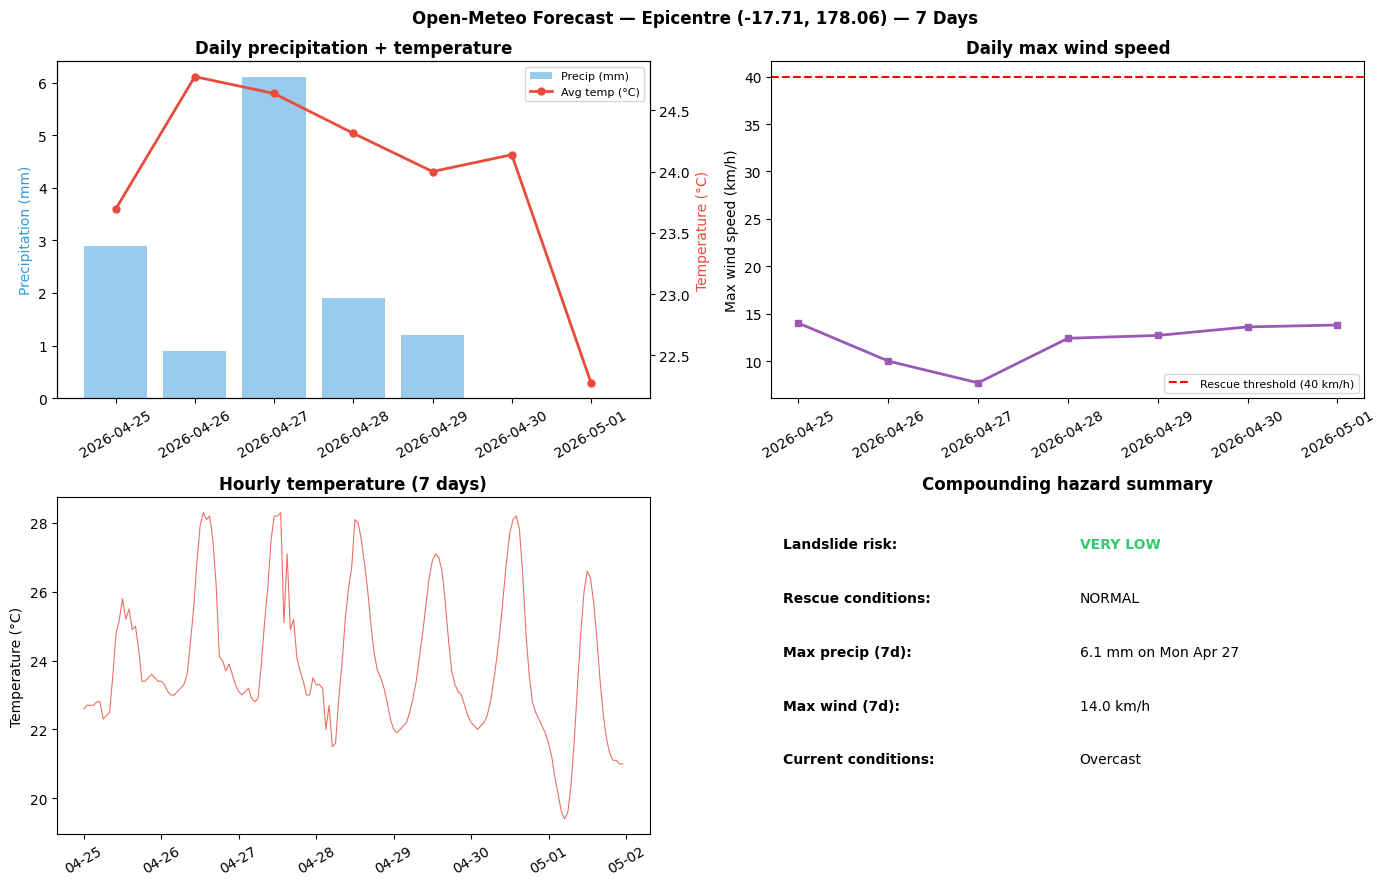

📊 Saved as nb5_openmeteo_forecast_result.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"Open-Meteo Forecast — Epicentre ({LAT:.2f}, {LON:.2f}) — 7 Days",
             fontsize=12, fontweight='bold')

# 1. Temperature + precipitation
ax = axes[0,0]; ax2 = ax.twinx()
ax.bar(daily["date"], daily["total_precip"], color='#3498db', alpha=0.5,
       width=0.8, label="Precip (mm)")
ax2.plot(daily["date"], daily["avg_temp"], color='#e74c3c', marker='o',
         linewidth=2, markersize=5, label="Avg temp (°C)")
ax.set_ylabel("Precipitation (mm)", color='#3498db')
ax2.set_ylabel("Temperature (°C)", color='#e74c3c')
ax.set_title("Daily precipitation + temperature", fontweight='bold')
ax.tick_params(axis='x', rotation=30)
l1,la1=ax.get_legend_handles_labels(); l2,la2=ax2.get_legend_handles_labels()
ax.legend(l1+l2,la1+la2,fontsize=8)

# 2. Wind speed
ax = axes[0,1]
ax.plot(daily["date"], daily["max_wind"], color='#9b59b6', marker='s',
        linewidth=2, markersize=5)
ax.axhline(40, color='red', linestyle='--', linewidth=1.5, label='Rescue threshold (40 km/h)')
ax.set_ylabel("Max wind speed (km/h)"); ax.legend(fontsize=8)
ax.set_title("Daily max wind speed", fontweight='bold')
ax.tick_params(axis='x', rotation=30)

# 3. Hourly temperature
ax = axes[1,0]
ax.plot(df["time"], df["temp"], color='#e74c3c', linewidth=0.8, alpha=0.8)
ax.set_ylabel("Temperature (°C)")
ax.set_title("Hourly temperature (7 days)", fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# 4. Compounding hazard summary
ax = axes[1,1]; ax.axis('off')
COLORS = {"VERY LOW":"#2ecc71","LOW":"#f1c40f","MODERATE":"#e67e22","HIGH":"#e74c3c"}
max_precip = daily["total_precip"].max()
max_precip_day = daily.loc[daily["total_precip"].idxmax(),"date"].strftime("%a %b %d")
hazards = [
    ("Landslide risk",    landslide),
    ("Rescue conditions", rescue),
    ("Max precip (7d)",   f"{max_precip:.1f} mm on {max_precip_day}"),
    ("Max wind (7d)",     f"{daily['max_wind'].max():.1f} km/h"),
    ("Current conditions",current['conditions']),
]
for i,(label,value) in enumerate(hazards):
    y=0.85-i*0.16
    color=COLORS.get(str(value),'black')
    ax.text(0.02,y,f"{label}:",fontweight='bold',fontsize=10,transform=ax.transAxes)
    ax.text(0.52,y,str(value),fontsize=10,color=color,fontweight='bold' if value in COLORS else 'normal',
            transform=ax.transAxes)
ax.set_title("Compounding hazard summary", fontweight='bold')

plt.tight_layout()
plt.savefig("nb5_openmeteo_forecast_result.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved as nb5_openmeteo_forecast_result.png")